<a href="https://colab.research.google.com/github/Meetra21/LLM_24/blob/main/Significance_Gain_Pair_Encoding_for_LLMs__cache_enabled.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import gc, torch

def hard_cleanup(*vars_to_delete):

    for v in vars_to_delete:
        try:
            del v
        except Exception:
            pass

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

    print("Cleanup done.")
    if torch.cuda.is_available():
        free, total = torch.cuda.mem_get_info()
        print(f"GPU free: {free/1024**3:.2f} GB / {total/1024**3:.2f} GB")

# Example usage:
# hard_cleanup(model_f, model_s)
hard_cleanup()

Cleanup done.
GPU free: 14.34 GB / 14.56 GB


In [26]:
!nvidia-smi

Wed Mar 18 00:32:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   78C    P0             35W /   70W |     227MiB /  15360MiB |     28%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [27]:
#Cell 1 — Install
!pip -q install datasets

In [28]:
#Cell 2 — Imports + seed + device
import re, math, time, random
from collections import Counter
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset

import numpy as np

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [29]:
#Cell 3 — Load WikiText-103 + normalize
ds = load_dataset("wikitext", "wikitext-103-raw-v1")

train_text = "\n".join(ds["train"]["text"])
val_text   = "\n".join(ds["validation"]["text"])
test_text  = "\n".join(ds["test"]["text"])

def normalize_space(s: str) -> str:
    s = re.sub(r"[ \t]+", " ", s)
    s = re.sub(r"\n{3,}", "\n\n", s)
    return s.strip()

train_text = normalize_space(train_text)
val_text   = normalize_space(val_text)
test_text  = normalize_space(test_text)

#
#
TRAIN_SIZE = 3_000_000
VAL_SIZE   = 1_000_000
TEST_SIZE  = 600_000

train_text_small = train_text[:TRAIN_SIZE]
val_text_small   = val_text[:VAL_SIZE]
test_text_small  = test_text[:TEST_SIZE]

print("train chars:", len(train_text_small))
print("val chars  :", len(val_text_small))
print("test chars :", len(test_text_small))


train chars: 3000000
val chars  : 1000000
test chars : 600000


In [30]:
# ==============================
# Run config + caching
# ==============================
# If you're on Colab and want to save GPU time, set USE_DRIVE=True.
USE_DRIVE = True
FORCE_RETRAIN_TOKENIZERS = True   # set True if you change tokenizer code/config
FORCE_RETRAIN_MODELS     = True   # set True if you change TinyGPT/training hyperparams

# Where to save artifacts
RUN_TAG = "run_cache_1M_200k"

# Training hyperparams
block_size = 256
epochs     = 20
batch_size = 64
lr         = 3e-4

import os, json, pickle, torch

# Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
device = DEVICE
print("Using device:", DEVICE)


if USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        SAVE_DIR = f"/content/drive/MyDrive/sgbpe_runs/{RUN_TAG}"
    except Exception as e:
        print("Drive mount skipped (not in Colab?):", e)
        USE_DRIVE = False
        SAVE_DIR = f"./sgbpe_runs/{RUN_TAG}"
else:
    SAVE_DIR = f"./sgbpe_runs/{RUN_TAG}"

os.makedirs(SAVE_DIR, exist_ok=True)
print("SAVE_DIR:", SAVE_DIR)

def _p(filename):
    return os.path.join(SAVE_DIR, filename)

def save_pickle(obj, filename):
    with open(_p(filename), "wb") as f:
        pickle.dump(obj, f)

def load_pickle(filename):
    with open(_p(filename), "rb") as f:
        return pickle.load(f)

def save_json(obj, filename):
    with open(_p(filename), "w") as f:
        json.dump(obj, f)

def load_json(filename):
    with open(_p(filename), "r") as f:
        return json.load(f)


Using device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SAVE_DIR: /content/drive/MyDrive/sgbpe_runs/run_cache_1M_200k


In [31]:
#Cell 4 — pretokenizer (English word-ish tokens)
def pretokenize_english(s: str) -> List[str]:
    """
    Pretokenize into word-ish units to speed up BPE training.
    Keeps leading space attached: ' the', ' verdict'
    Splits punctuation and newlines into separate tokens.
    """
    # order matters: handle paragraph breaks/newlines first
    pattern = r"\n\n|\n| ?[A-Za-z]+| ?\d+| ?[^A-Za-z0-9\s]+| +"
    return re.findall(pattern, s)


def pretokenize_chars(s: str) -> List[str]:
    # Character-level base tokens
    return list(s)

In [32]:
#Cell 5 — Compression-first significance score (tokenizer)
def significance_gain_score(
    cxy: int,
    cx: int,
    cy: int,
    N: int,
    eps: float = 1e-9,
    gain_power: float = 1.35,
    sig_weight: float = 0.18,
    pmi_weight: float = 0.08,
    clamp_pmi: float = 3.0,
) -> float:
    """
    Compression-first score.
    - Primary objective: merge frequency (compression) via log1p(cxy)^gain_power
    - Secondary objective: cohesion (z-score) and PMI, used multiplicatively (tie-break style)

    Returns a single scalar score (higher is better).
    """
    N = max(N, 1)
    expected = (cx * cy) / N

    # z-score style cohesion (only positive surprises)
    z = (cxy - expected) / math.sqrt(expected + eps)
    z = max(z, 0.0)

    # PMI cohesion (only positive PMI)
    pmi = math.log((cxy * N + eps) / (cx * cy + eps))
    pmi = max(0.0, min(clamp_pmi, pmi))

    # Compression term
    compression = math.log1p(cxy) ** gain_power

    # Multiplicative refinement (prevents cohesion from overpowering compression)
    refine = 1.0 + sig_weight * z + pmi_weight * pmi
    return compression * refine


In [33]:
#Cell 6 — Tokenizer config + tokenizer class
@dataclass
class BPEConfig:
    vocab_size: int = 2000
    min_pair_count: int = 3
    eps: float = 1e-9
    unk_token: str = "<unk>"

    # Compression-first controls
    gain_power: float = 1.35
    sig_weight: float = 0.18
    pmi_weight: float = 0.08
    clamp_pmi: float = 3.0

    # Candidate search
    candidate_topk: int = 8000
    max_token_len: int = 48

    # Strong space/newline preference (helps compression)
    boundary_bonus: float = 0.35

    # Generalization / anti-overfit: require merges to appear in an internal heldout slice
    holdout_frac: float = 0.08          # last 8% of TRAIN used as tokenizer-heldout
    min_holdout_count: int = 2          # pair must appear at least this many times in heldout
    holdout_weight: float = 0.25        # bonus proportional to heldout frequency


class SimpleBPE:
    def __init__(self, config: BPEConfig, mode: str = "freq"):
        assert mode in ("freq", "sigz")
        self.cfg = config
        self.mode = mode
        self.merges: List[Tuple[Tuple[str, str], str]] = []
        self.vocab: Dict[str, int] = {}
        self.id_to_tok: List[str] = []

    def _get_pair_counts(self, seq: List[str]) -> Counter:
        return Counter(zip(seq, seq[1:]))

    def _get_symbol_counts(self, seq: List[str]) -> Counter:
        return Counter(seq)

    def _apply_merge_once(self, seq: List[str], pair: Tuple[str, str], merged: str) -> List[str]:
        a, b = pair
        out = []
        i = 0
        L = len(seq)
        while i < L:
            if i < L - 1 and seq[i] == a and seq[i + 1] == b:
                out.append(merged)
                i += 2
            else:
                out.append(seq[i])
                i += 1
        return out

    def _choose_best_pair(
        self,
        seq: List[str],
        hold_pair_counts: Optional[Counter] = None
    ) -> Optional[Tuple[str, str]]:
        pair_counts = self._get_pair_counts(seq)
        candidates = [(p, c) for p, c in pair_counts.items() if c >= self.cfg.min_pair_count]
        if not candidates:
            return None

        # Baseline BPE = max count only (best compression on TRAIN)
        if self.mode == "freq":
            best_pair, _ = max(candidates, key=lambda x: x[1])
            return best_pair

        # sigz: keep only top-frequency candidates, then re-rank with compression-first score.
        sym_counts = self._get_symbol_counts(seq)
        N = max(len(seq) - 1, 1)

        candidates.sort(key=lambda x: x[1], reverse=True)
        topk = min(len(candidates), self.cfg.candidate_topk if self.cfg.candidate_topk else len(candidates))
        candidates = candidates[:topk]

        best_pair = None
        best_score = -1e30

        for (a, b), cxy in candidates:
            merged = a + b
            if self.cfg.max_token_len and len(merged) > self.cfg.max_token_len:
                continue

            # Heldout filter/bonus to reduce overfitting to TRAIN-only merges
            c_hold = 0
            if hold_pair_counts is not None:
                c_hold = hold_pair_counts.get((a, b), 0)
                if c_hold < self.cfg.min_holdout_count:
                    continue

            cx = sym_counts[a]
            cy = sym_counts[b]

            score = significance_gain_score(
                cxy=cxy, cx=cx, cy=cy, N=N,
                eps=self.cfg.eps,
                gain_power=self.cfg.gain_power,
                sig_weight=self.cfg.sig_weight,
                pmi_weight=self.cfg.pmi_weight,
                clamp_pmi=self.cfg.clamp_pmi,
            )

            # Space/newline merges are extremely compressive and generalize well
            if self.cfg.boundary_bonus > 0:
                if a.endswith(" ") or b.startswith(" ") or ("\n" in a) or ("\n" in b):
                    score += self.cfg.boundary_bonus * math.log1p(cxy)

            # Extra generalization bonus based on heldout frequency
            if hold_pair_counts is not None and self.cfg.holdout_weight > 0:
                score += self.cfg.holdout_weight * math.log1p(c_hold)

            if score > best_score:
                best_score = score
                best_pair = (a, b)

        # Fallback: if everything filtered out (rare), fall back to best compression
        if best_pair is None:
            best_pair, _ = max(candidates, key=lambda x: x[1])
        return best_pair

    def train(self, text: str, progress_every: int = 200):
        seq_all = pretokenize_chars(text)

        # Internal tokenizer-holdout split (no validation leakage)
        hold_n = int(len(seq_all) * self.cfg.holdout_frac)
        hold_n = max(0, min(hold_n, len(seq_all) // 2))
        if hold_n > 0:
            seq = seq_all[:-hold_n]
            seq_hold = seq_all[-hold_n:]
            hold_pair_counts = self._get_pair_counts(seq_hold)
        else:
            seq = seq_all
            hold_pair_counts = None

        # base vocab from TRAIN pre-tokens + <unk>
        base_vocab = sorted(set(seq_all))
        if self.cfg.unk_token not in base_vocab:
            base_vocab.append(self.cfg.unk_token)

        self.merges = []

        def current_vocab_size(s):
            return len(set(s))

        target = self.cfg.vocab_size
        t0 = time.time()
        it = 0

        while current_vocab_size(seq) < target:
            best_pair = self._choose_best_pair(seq, hold_pair_counts=hold_pair_counts)
            if best_pair is None:
                break

            merged = best_pair[0] + best_pair[1]
            self.merges.append((best_pair, merged))

            # apply merge to TRAIN seq, and also to holdout seq to keep hold counts consistent
            seq = self._apply_merge_once(seq, best_pair, merged)
            if hold_pair_counts is not None and hold_n > 0:
                seq_hold = self._apply_merge_once(seq_hold, best_pair, merged)
                hold_pair_counts = self._get_pair_counts(seq_hold)

            it += 1
            if it % progress_every == 0:
                print(f"[{self.mode}] merges={it} vocab={current_vocab_size(seq)} elapsed={time.time()-t0:.1f}s")

            if it > 20000:
                print("[warn] stopping at 20000 merges (safety).")
                break

        # Final vocab
        tokens = set(base_vocab)
        for (_, _), merged in self.merges:
            tokens.add(merged)
        tokens.add(self.cfg.unk_token)

        self.id_to_tok = sorted(tokens)
        self.vocab = {t: i for i, t in enumerate(self.id_to_tok)}
        print(f"[{self.mode}] training done: merges={len(self.merges)} final_vocab={len(self.vocab)}")

    def encode(self, text: str) -> List[int]:
        UNK = self.cfg.unk_token
        unk_id = self.vocab[UNK]

        seq = pretokenize_chars(text)

        # Map unseen base tokens to UNK (should be rare with same domain)
        seq = [t if t in self.vocab else UNK for t in seq]

        for (a, b), merged in self.merges:
            seq = self._apply_merge_once(seq, (a, b), merged)

        return [self.vocab.get(t, unk_id) for t in seq]

    def stats(self, encoded: List[int], raw_text: str) -> Dict[str, float]:
        toks = len(encoded)
        chars = max(len(raw_text), 1)
        used = len(set(encoded))
        util = used / max(len(self.vocab), 1)
        return {
            "tokens_per_char": toks / chars,
            "vocab_used_frac": util,
            "num_tokens": toks,
            "num_chars": chars,
        }


In [34]:
#Cell 7 — Train tokenizers + encode + show stats (with caching)
def show_stats(name, tok, tr, va, te, train_text, val_text, test_text):
    st_tr = tok.stats(tr, train_text)
    st_va = tok.stats(va, val_text)
    st_te = tok.stats(te, test_text)
    print(f"\n{name}")
    print(f"  train tpc={st_tr['tokens_per_char']:.4f}  vocab_used={st_tr['vocab_used_frac']:.3f}")
    print(f"  val   tpc={st_va['tokens_per_char']:.4f}  vocab_used={st_va['vocab_used_frac']:.3f}")
    print(f"  test  tpc={st_te['tokens_per_char']:.4f}  vocab_used={st_te['vocab_used_frac']:.3f}")

vocab_size = 600

# Baseline: pure frequency BPE
cfg_freq = BPEConfig(
    vocab_size=vocab_size,
    min_pair_count=5,        # keep baseline stable
)

# Significance-Gain: compression-first + internal heldout to reduce overfitting
cfg_sigz = BPEConfig(
    vocab_size=vocab_size,
    min_pair_count=3,
    gain_power=1.35,
    sig_weight=0.18,
    pmi_weight=0.08,
    clamp_pmi=3.0,
    candidate_topk=8000,
    max_token_len=48,
    boundary_bonus=0.35,
    holdout_frac=0.08,
    min_holdout_count=2,
    holdout_weight=0.25,
)

TOKEN_CACHE_FILES = ["tok_freq.pkl", "tok_sigz.pkl", "encoded_bundle.pkl", "token_cfg.json"]
use_cache = (not FORCE_RETRAIN_TOKENIZERS) and all(os.path.exists(_p(f)) for f in TOKEN_CACHE_FILES)

if use_cache:
    print("✅ Loading cached tokenizers + encodings...")
    tok_freq = load_pickle("tok_freq.pkl")
    tok_sigz = load_pickle("tok_sigz.pkl")
    bundle = load_pickle("encoded_bundle.pkl")
    tr_f, va_f, te_f = bundle["tr_f"], bundle["va_f"], bundle["te_f"]
    tr_s, va_s, te_s = bundle["tr_s"], bundle["va_s"], bundle["te_s"]
else:
    print("Training standard BPE...")
    tok_freq = SimpleBPE(cfg_freq, mode="freq")
    tok_freq.train(train_text_small, progress_every=200)

    print("\nTraining significance-gain BPE...")
    tok_sigz = SimpleBPE(cfg_sigz, mode="sigz")
    tok_sigz.train(train_text_small, progress_every=200)

    tr_f = tok_freq.encode(train_text_small)
    va_f = tok_freq.encode(val_text_small)
    te_f = tok_freq.encode(test_text_small)

    tr_s = tok_sigz.encode(train_text_small)
    va_s = tok_sigz.encode(val_text_small)
    te_s = tok_sigz.encode(test_text_small)

    # Save
    print("💾 Saving tokenizers + encodings to cache...")
    save_pickle(tok_freq, "tok_freq.pkl")
    save_pickle(tok_sigz, "tok_sigz.pkl")
    save_pickle({"tr_f": tr_f, "va_f": va_f, "te_f": te_f,
                 "tr_s": tr_s, "va_s": va_s, "te_s": te_s}, "encoded_bundle.pkl")
    save_json({"cfg_freq": cfg_freq.__dict__, "cfg_sigz": cfg_sigz.__dict__}, "token_cfg.json")

show_stats("Standard BPE", tok_freq, tr_f, va_f, te_f, train_text_small, val_text_small, test_text_small)
show_stats("Significance-Gain BPE", tok_sigz, tr_s, va_s, te_s, train_text_small, val_text_small, test_text_small)


Training standard BPE...
[freq] training done: merges=168 final_vocab=635

Training significance-gain BPE...
[sigz] training done: merges=171 final_vocab=638
💾 Saving tokenizers + encodings to cache...

Standard BPE
  train tpc=0.5187  vocab_used=0.991
  val   tpc=0.5191  vocab_used=0.482
  test  tpc=0.5231  vocab_used=0.479

Significance-Gain BPE
  train tpc=0.5773  vocab_used=0.987
  val   tpc=0.5752  vocab_used=0.478
  test  tpc=0.5840  vocab_used=0.476


In [35]:
#Cell 8 — Dataset blocks for LM
class LMBlocks(Dataset):
    def __init__(self, ids: List[int], block_size: int = 256, stride: int = 256):
        self.ids = torch.tensor(ids, dtype=torch.long)
        self.block = block_size
        self.starts = list(range(0, max(len(self.ids) - block_size - 1, 0), stride))

    def __len__(self):
        return len(self.starts)

    def __getitem__(self, idx):
        s = self.starts[idx]
        x = self.ids[s:s+self.block]
        y = self.ids[s+1:s+self.block+1]
        return x, y

In [36]:
#Cell 9 — Tiny GPT model
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float):
        super().__init__()
        assert d_model % n_heads == 0
        self.nh = n_heads
        self.dk = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv(x)
        q, k, v = qkv.chunk(3, dim=-1)

        q = q.view(B, T, self.nh, self.dk).transpose(1, 2)
        k = k.view(B, T, self.nh, self.dk).transpose(1, 2)
        v = v.view(B, T, self.nh, self.dk).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.dk)
        mask = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1)
        att = att.masked_fill(mask, float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.drop(att)

        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.drop(self.proj(y))
        return y

class TransformerBlock(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float, mlp_mult: int = 4):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, mlp_mult * d_model),
            nn.GELU(),
            nn.Linear(mlp_mult * d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

class TinyGPT(nn.Module):
    def __init__(self, vocab_size: int, block_size: int, d_model=192, n_heads=4, n_layers=4, dropout=0.1):
        super().__init__()
        self.block_size = block_size
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(block_size, d_model)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([TransformerBlock(d_model, n_heads, dropout) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, idx):
        B, T = idx.shape
        pos = torch.arange(0, T, device=idx.device)
        x = self.tok_emb(idx) + self.pos_emb(pos)[None, :, :]
        x = self.drop(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.ln_f(x)
        return self.head(x)

In [37]:
#Cell 10 — Train/eval helpers
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    correct = 0

    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        logits = model(x)
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1), reduction="sum")
        total_loss += loss.item()
        total_tokens += y.numel()

        pred = logits.argmax(dim=-1)
        correct += (pred == y).sum().item()

    avg_nll = total_loss / max(total_tokens, 1)
    ppl = math.exp(min(avg_nll, 20))
    acc = correct / max(total_tokens, 1)
    return avg_nll, ppl, acc

def train_lm(train_ids, val_ids, vocab_size, block_size=256, batch_size=64, epochs=3, lr=3e-4):
    """Train TinyGPT and return (model, history).

    history keys: epoch, train_nll, val_nll, val_ppl, val_acc, sec
    """
    train_ds = LMBlocks(train_ids, block_size=block_size, stride=block_size)
    val_ds   = LMBlocks(val_ids, block_size=block_size, stride=block_size)

    use_pin = (str(device).startswith("cuda"))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=0, pin_memory=use_pin)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=use_pin)

    model = TinyGPT(vocab_size=vocab_size, block_size=block_size).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)

    history = {"epoch": [], "train_nll": [], "val_nll": [], "val_ppl": [], "val_acc": [], "sec": []}

    for ep in range(1, epochs + 1):
        model.train()
        t0 = time.time()
        running = 0.0
        tokens = 0

        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            logits = model(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1))
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            running += loss.item() * y.numel()
            tokens += y.numel()

        train_nll = running / max(tokens, 1)
        val_nll, val_ppl, val_acc = evaluate(model, val_loader, device)
        sec = time.time() - t0
        print(f"epoch {ep:02d} | train_nll={train_nll:.4f} | val_nll={val_nll:.4f} | val_ppl={val_ppl:.2f} | val_acc={val_acc*100:.2f}% | {sec:.1f}s")

        history["epoch"].append(ep)
        history["train_nll"].append(train_nll)
        history["val_nll"].append(val_nll)
        history["val_ppl"].append(val_ppl)
        history["val_acc"].append(val_acc)
        history["sec"].append(sec)

    return model, history


In [38]:
# ==============================
# Cell 11 — MAIN COMPARISON (multi-seed) + VOCAB GRID (FIXED)
# ==============================
import numpy as np
import random
import torch
from torch.utils.data import DataLoader

print("\n==============================")
print("MAIN COMPARISON (multi-seed)")
print("==============================")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# train_lm() uses `device` internally
device = DEVICE

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# --------- Build configs (NO alpha_count / use_gain in this notebook) ---------
BASE_VOCAB = 600

cfg_f = BPEConfig(
    vocab_size=BASE_VOCAB,
    min_pair_count=5,
    # baseline (freq-only) mode still uses these knobs but with sig weights ~0
    gain_power=1.20,
    sig_weight=0.0,
    pmi_weight=0.0,
    clamp_pmi=3.0,
    candidate_topk=8000,
    max_token_len=60,
    boundary_bonus=0.0,
    # holdout regularization disabled for baseline
    holdout_frac=0.0,
    min_holdout_count=0,
    holdout_weight=0.0,
)

cfg_s = BPEConfig(
    vocab_size=BASE_VOCAB,
    min_pair_count=3,
    # compression-first + significance refinement
    gain_power=1.35,
    sig_weight=0.35,
    pmi_weight=0.15,
    clamp_pmi=3.0,
    candidate_topk=8000,
    max_token_len=60,
    boundary_bonus=0.45,
    # internal heldout regularization (to reduce overfit merges)
    holdout_frac=0.10,
    min_holdout_count=2,
    holdout_weight=0.20,
)

SEEDS = [0, 1, 2]
epochs = 6
block_size = 256
batch_size = 64
lr = 3e-4

def run_one_seed(seed: int, cfg_f: BPEConfig, cfg_s: BPEConfig):
    set_seed(seed)

    # Tokenizers
    tok_f = SimpleBPE(cfg_f, mode="freq")
    tok_s = SimpleBPE(cfg_s, mode="sigz")

    tok_f.train(train_text_small, progress_every=200)
    tok_s.train(train_text_small, progress_every=200)

    tr_f = tok_f.encode(train_text_small)
    va_f = tok_f.encode(val_text_small)
    te_f = tok_f.encode(test_text_small)

    tr_s = tok_s.encode(train_text_small)
    va_s = tok_s.encode(val_text_small)
    te_s = tok_s.encode(test_text_small)

    # Train LMs
    model_f, _ = train_lm(
        tr_f, va_f,
        vocab_size=len(tok_f.vocab),
        block_size=block_size,
        batch_size=batch_size,
        epochs=epochs,
        lr=lr,
    )
    model_s, _ = train_lm(
        tr_s, va_s,
        vocab_size=len(tok_s.vocab),
        block_size=block_size,
        batch_size=batch_size,
        epochs=epochs,
        lr=lr,
    )

    # Evaluate
    val_loader_f = DataLoader(LMBlocks(va_f, block_size=block_size, stride=block_size), batch_size=batch_size, shuffle=False)
    val_loader_s = DataLoader(LMBlocks(va_s, block_size=block_size, stride=block_size), batch_size=batch_size, shuffle=False)
    te_loader_f  = DataLoader(LMBlocks(te_f, block_size=block_size, stride=block_size), batch_size=batch_size, shuffle=False)
    te_loader_s  = DataLoader(LMBlocks(te_s, block_size=block_size, stride=block_size), batch_size=batch_size, shuffle=False)

    val_nll_f, val_ppl_f, val_acc_f = evaluate(model_f, val_loader_f, DEVICE)
    val_nll_s, val_ppl_s, val_acc_s = evaluate(model_s, val_loader_s, DEVICE)
    te_nll_f,  te_ppl_f,  te_acc_f  = evaluate(model_f, te_loader_f, DEVICE)
    te_nll_s,  te_ppl_s,  te_acc_s  = evaluate(model_s, te_loader_s, DEVICE)

    # Tokenizer stats
    st_va_f = tok_f.stats(va_f, val_text_small)
    st_te_f = tok_f.stats(te_f, test_text_small)
    st_va_s = tok_s.stats(va_s, val_text_small)
    st_te_s = tok_s.stats(te_s, test_text_small)

    return {
        "seed": seed,
        "val_ppl_f": val_ppl_f, "val_ppl_s": val_ppl_s,
        "test_ppl_f": te_ppl_f, "test_ppl_s": te_ppl_s,
        "val_tpc_f": st_va_f["tokens_per_char"], "val_tpc_s": st_va_s["tokens_per_char"],
        "test_tpc_f": st_te_f["tokens_per_char"], "test_tpc_s": st_te_s["tokens_per_char"],
        "val_nllc_f": val_nll_f * st_va_f["tokens_per_char"],
        "val_nllc_s": val_nll_s * st_va_s["tokens_per_char"],
        "test_nllc_f": te_nll_f * st_te_f["tokens_per_char"],
        "test_nllc_s": te_nll_s * st_te_s["tokens_per_char"],
    }

rows = []
for seed in SEEDS:
    rows.append(run_one_seed(seed, cfg_f, cfg_s))

def mean_std(key):
    vals = [r[key] for r in rows]
    return float(np.mean(vals)), float(np.std(vals))

print("\nAverages over seeds:", SEEDS)
for k in ["val_ppl_f","val_ppl_s","test_ppl_f","test_ppl_s","val_tpc_f","val_tpc_s","test_tpc_f","test_tpc_s","val_nllc_f","val_nllc_s","test_nllc_f","test_nllc_s"]:
    m, s = mean_std(k)
    print(f"{k:12s}: {m:.4f} ± {s:.4f}")

# ==============================
# VOCAB GRID (optional)
# ==============================
print("\n==============================")
print("VOCAB GRID (optional)")
print("==============================")

VOCAB_GRID = [300, 400, 600, 800, 1200]
grid_rows = []

for V in VOCAB_GRID:
    # Baseline config for this vocab size
    cfg_fv = BPEConfig(
        vocab_size=V,
        min_pair_count=5,
        gain_power=1.20,
        sig_weight=0.0,
        pmi_weight=0.0,
        clamp_pmi=3.0,
        candidate_topk=8000,
        max_token_len=60,
        boundary_bonus=0.0,
        holdout_frac=0.0,
        min_holdout_count=0,
        holdout_weight=0.0,
    )

    # Sig config for this vocab size
    cfg_sv = BPEConfig(
        vocab_size=V,
        min_pair_count=3,
        gain_power=1.35,
        sig_weight=0.35,
        pmi_weight=0.15,
        clamp_pmi=3.0,
        candidate_topk=8000,
        max_token_len=60,
        boundary_bonus=0.45,
        holdout_frac=0.10,
        min_holdout_count=2,
        holdout_weight=0.20,
    )

    # Single seed for grid to keep runtime reasonable
    r = run_one_seed(0, cfg_fv, cfg_sv)
    grid_rows.append((V, r["val_nllc_f"], r["val_nllc_s"], r["test_nllc_f"], r["test_nllc_s"], r["val_tpc_f"], r["val_tpc_s"]))

print("\nVocab | val_nll/char (freq, sig) | test_nll/char (freq, sig) | val_tpc (freq, sig)")
for V, vnf, vns, tnf, tns, tpcf, tpcs in grid_rows:
    print(f"{V:5d} | {vnf:.6f}, {vns:.6f} | {tnf:.6f}, {tns:.6f} | {tpcf:.4f}, {tpcs:.4f}")


MAIN COMPARISON (multi-seed)
Using device: cuda
[freq] training done: merges=139 final_vocab=606
[sigz] training done: merges=179 final_vocab=646
epoch 01 | train_nll=5.0617 | val_nll=4.4310 | val_ppl=84.01 | val_acc=9.10% | 17.6s
epoch 02 | train_nll=4.1545 | val_nll=3.9354 | val_ppl=51.18 | val_acc=12.03% | 14.6s
epoch 03 | train_nll=3.8968 | val_nll=3.8218 | val_ppl=45.69 | val_acc=12.37% | 13.4s
epoch 04 | train_nll=3.8083 | val_nll=3.7698 | val_ppl=43.37 | val_acc=12.67% | 13.3s
epoch 05 | train_nll=3.7576 | val_nll=3.7369 | val_ppl=41.97 | val_acc=12.97% | 13.3s
epoch 06 | train_nll=3.7213 | val_nll=3.7109 | val_ppl=40.89 | val_acc=13.27% | 13.6s
epoch 01 | train_nll=4.6631 | val_nll=4.0900 | val_ppl=59.74 | val_acc=12.25% | 15.3s
epoch 02 | train_nll=3.9029 | val_nll=3.7552 | val_ppl=42.74 | val_acc=14.03% | 15.1s
epoch 03 | train_nll=3.7166 | val_nll=3.6628 | val_ppl=38.97 | val_acc=14.32% | 14.7s
epoch 04 | train_nll=3.6469 | val_nll=3.6193 | val_ppl=37.31 | val_acc=14.50% | 

In [39]:
# Cell 13 — Final single-run comparison (with model caching)
import math
from torch.utils.data import DataLoader

LN2 = math.log(2.0)

def nll_char(nll_tok: float, tokens_per_char: float) -> float:
    return nll_tok * tokens_per_char

def bpc(nll_tok: float, tokens_per_char: float) -> float:
    return nll_char(nll_tok, tokens_per_char) / LN2

def pct_improve(old, new):
    return (old - new) / old * 100.0

MODEL_CACHE_FILES = ["model_standard.pt", "model_sig.pt", "hist_standard.json", "hist_sig.json"]
use_model_cache = (not FORCE_RETRAIN_MODELS) and all(os.path.exists(_p(f)) for f in MODEL_CACHE_FILES)

if use_model_cache:
    print("✅ Loading cached models + histories...")
    model_f = TinyGPT(vocab_size=len(tok_freq.vocab), block_size=block_size).to(device)
    model_s = TinyGPT(vocab_size=len(tok_sigz.vocab), block_size=block_size).to(device)
    model_f.load_state_dict(torch.load(_p("model_standard.pt"), map_location=device))
    model_s.load_state_dict(torch.load(_p("model_sig.pt"), map_location=device))
    hist_f = load_json("hist_standard.json")
    hist_s = load_json("hist_sig.json")
else:
    print("\n=== Train LM with standard BPE ===")
    model_f, hist_f = train_lm(
        tr_f, va_f,
        vocab_size=len(tok_freq.vocab),
        block_size=block_size,
        batch_size=batch_size,
        epochs=epochs,
        lr=lr,
    )

    print("\n=== Train LM with significance-gain BPE ===")
    model_s, hist_s = train_lm(
        tr_s, va_s,
        vocab_size=len(tok_sigz.vocab),
        block_size=block_size,
        batch_size=batch_size,
        epochs=epochs,
        lr=lr,
    )

    print("💾 Saving models + histories to cache...")
    torch.save(model_f.state_dict(), _p("model_standard.pt"))
    torch.save(model_s.state_dict(), _p("model_sig.pt"))
    save_json(hist_f, "hist_standard.json")
    save_json(hist_s, "hist_sig.json")

# Evaluate
val_loader_f = DataLoader(LMBlocks(va_f, block_size=block_size, stride=block_size), batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)
val_loader_s = DataLoader(LMBlocks(va_s, block_size=block_size, stride=block_size), batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)
te_loader_f  = DataLoader(LMBlocks(te_f, block_size=block_size, stride=block_size), batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)
te_loader_s  = DataLoader(LMBlocks(te_s, block_size=block_size, stride=block_size), batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

val_nll_f, val_ppl_f, val_acc_f = evaluate(model_f, val_loader_f, device)
val_nll_s, val_ppl_s, val_acc_s = evaluate(model_s, val_loader_s, device)
te_nll_f,  te_ppl_f,  te_acc_f  = evaluate(model_f, te_loader_f, device)
te_nll_s,  te_ppl_s,  te_acc_s  = evaluate(model_s, te_loader_s, device)

st_va_f = tok_freq.stats(va_f, val_text_small)
st_te_f = tok_freq.stats(te_f, test_text_small)
st_va_s = tok_sigz.stats(va_s, val_text_small)
st_te_s = tok_sigz.stats(te_s, test_text_small)

val_tpc_f, test_tpc_f = st_va_f["tokens_per_char"], st_te_f["tokens_per_char"]
val_tpc_s, test_tpc_s = st_va_s["tokens_per_char"], st_te_s["tokens_per_char"]

val_bpc_f  = bpc(val_nll_f, val_tpc_f)
val_bpc_s  = bpc(val_nll_s, val_tpc_s)
test_bpc_f = bpc(te_nll_f,  test_tpc_f)
test_bpc_s = bpc(te_nll_s,  test_tpc_s)

print("\n====================")
print("FINAL COMPARISON")
print("====================")
print(f"train_size used: {len(train_text_small):,} characters")
print(f"Standard BPE     | val_ppl={val_ppl_f:.2f} | val_acc={val_acc_f*100:.2f}% | test_ppl={te_ppl_f:.2f} | test_acc={te_acc_f*100:.2f}%")
print(f"Significance-BPE | val_ppl={val_ppl_s:.2f} | val_acc={val_acc_s*100:.2f}% | test_ppl={te_ppl_s:.2f} | test_acc={te_acc_s*100:.2f}%")

print("\nTokenizer stats (tokens per char)")
print(f"Standard BPE     | val_tpc={val_tpc_f:.4f} | test_tpc={test_tpc_f:.4f}")
print(f"Significance-BPE | val_tpc={val_tpc_s:.4f} | test_tpc={test_tpc_s:.4f}")

print("\nTokenizer-invariant metrics")
print(f"Standard BPE     | val_nll/char={nll_char(val_nll_f, val_tpc_f):.6f} | test_nll/char={nll_char(te_nll_f, test_tpc_f):.6f} | val_bpc={val_bpc_f:.4f} | test_bpc={test_bpc_f:.4f}")
print(f"Significance-BPE | val_nll/char={nll_char(val_nll_s, val_tpc_s):.6f} | test_nll/char={nll_char(te_nll_s, test_tpc_s):.6f} | val_bpc={val_bpc_s:.4f} | test_bpc={test_bpc_s:.4f}")

print("\nImprovements (positive means Significance-Gain BPE is better)")
print(f"Val  PPL improvement (%): {pct_improve(val_ppl_f, val_ppl_s):.2f}")
print(f"Test PPL improvement (%): {pct_improve(te_ppl_f,  te_ppl_s):.2f}")
print(f"Val  BPC improvement (%): {pct_improve(val_bpc_f,  val_bpc_s):.2f}")
print(f"Test BPC improvement (%): {pct_improve(test_bpc_f, test_bpc_s):.2f}")



=== Train LM with standard BPE ===
epoch 01 | train_nll=5.2019 | val_nll=4.6123 | val_ppl=100.72 | val_acc=8.07% | 12.9s
epoch 02 | train_nll=4.3016 | val_nll=4.0530 | val_ppl=57.57 | val_acc=11.45% | 13.0s
epoch 03 | train_nll=4.0094 | val_nll=3.9222 | val_ppl=50.51 | val_acc=11.95% | 13.2s
epoch 04 | train_nll=3.9084 | val_nll=3.8626 | val_ppl=47.59 | val_acc=12.20% | 13.3s
epoch 05 | train_nll=3.8505 | val_nll=3.8216 | val_ppl=45.68 | val_acc=12.55% | 13.2s
epoch 06 | train_nll=3.8105 | val_nll=3.7970 | val_ppl=44.57 | val_acc=12.72% | 13.1s

=== Train LM with significance-gain BPE ===
epoch 01 | train_nll=4.6531 | val_nll=4.0987 | val_ppl=60.26 | val_acc=12.60% | 14.6s
epoch 02 | train_nll=3.8919 | val_nll=3.7414 | val_ppl=42.16 | val_acc=14.10% | 14.7s
epoch 03 | train_nll=3.7007 | val_nll=3.6502 | val_ppl=38.48 | val_acc=14.48% | 14.8s
epoch 04 | train_nll=3.6314 | val_nll=3.6068 | val_ppl=36.85 | val_acc=14.65% | 14.7s
epoch 05 | train_nll=3.5914 | val_nll=3.5790 | val_ppl=35.8

## Epoch-by-epoch visualization (Validation)
These plots compare **Standard BPE** vs **Significance-Gain BPE** across epochs.

In [ ]:
import pandas as pd, numpy as np, math
import matplotlib.pyplot as plt

LN2 = math.log(2.0)

def to_df(hist, label, val_tpc):
    df = pd.DataFrame(hist)
    df["model"] = label
    df["val_tpc"] = val_tpc
    df["val_nll_char"] = df["val_nll"] * df["val_tpc"]
    df["val_bpc"] = df["val_nll_char"] / LN2
    return df

df_f = to_df(hist_f, "Standard BPE", val_tpc_f)
df_s = to_df(hist_s, "Significance-BPE", val_tpc_s)
df = pd.concat([df_f, df_s], ignore_index=True)

pivot = df.pivot(index="epoch", columns="model", values=["val_ppl","val_nll","val_acc","val_nll_char","val_bpc","sec"])
pivot.columns = [f"{a} | {b}" for a,b in pivot.columns]
pivot = pivot.reset_index()
display(pivot)


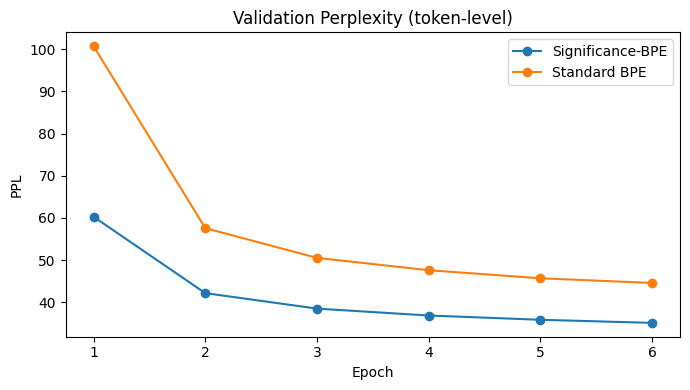

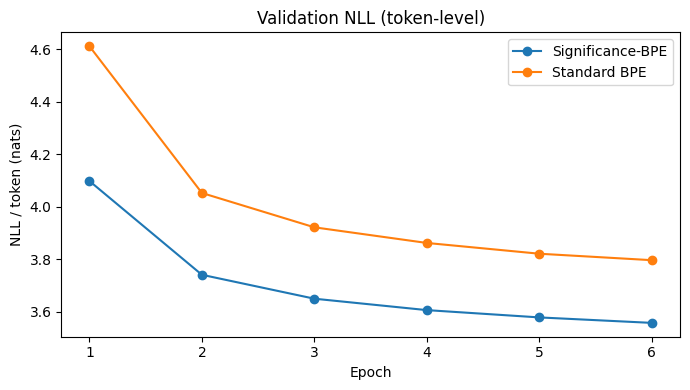

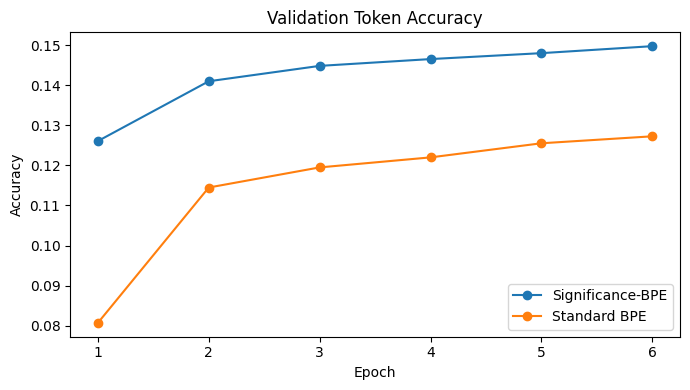

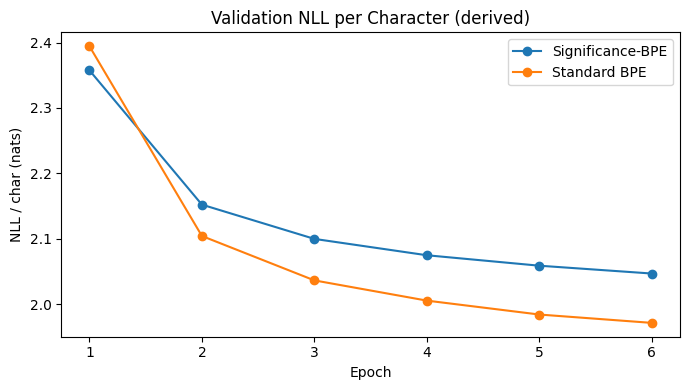

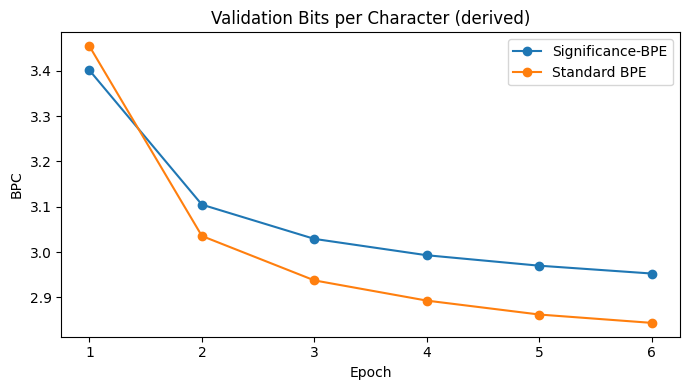

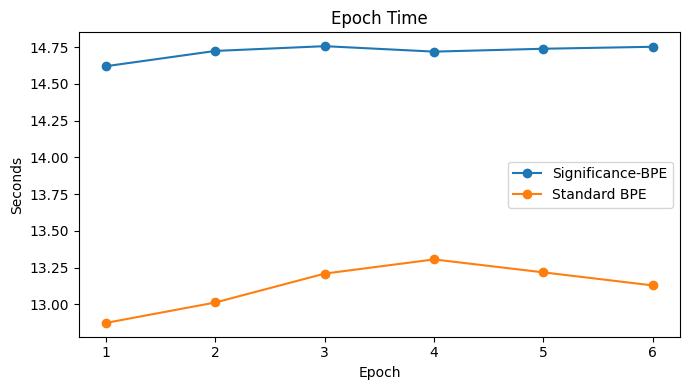

In [41]:
def plot_metric(df, metric, title, ylabel):
    plt.figure(figsize=(7,4))
    for name, g in df.groupby("model"):
        plt.plot(g["epoch"], g[metric], marker="o", label=name)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_metric(df, "val_ppl",      "Validation Perplexity (token-level)", "PPL")
plot_metric(df, "val_nll",      "Validation NLL (token-level)", "NLL / token (nats)")
plot_metric(df, "val_acc",      "Validation Token Accuracy", "Accuracy")
plot_metric(df, "val_nll_char", "Validation NLL per Character (derived)", "NLL / char (nats)")
plot_metric(df, "val_bpc",      "Validation Bits per Character (derived)", "BPC")
plot_metric(df, "sec",          "Epoch Time", "Seconds")


,epoch,PPL_improve_%,BPC_improve_%,NLL_char_improve_%,Acc_diff_pp
0,1,40.168947,1.539440,1.539440,4.534564
1,2,26.777498,-2.279423,-2.279423,2.650176
2,3,23.811834,-3.116815,-3.116815,2.532044
3,4,22.573493,-3.460767,-3.460767,2.451844
4,5,21.543626,-3.765112,-3.765112,2.247787
5,6,21.248920,-3.828959,-3.828959,2.248056


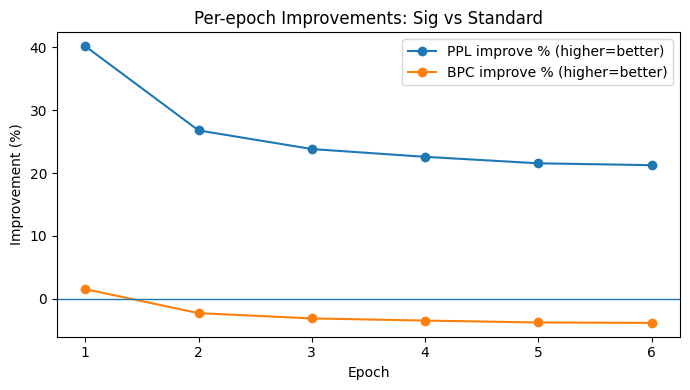

In [42]:
# Per-epoch improvement table + plot
mf = df_f.set_index("epoch")
ms = df_s.set_index("epoch")

def pct_improve(old, new):
    return (old - new) / old * 100.0

imp = pd.DataFrame(index=mf.index)
imp["PPL_improve_%"] = pct_improve(mf["val_ppl"], ms["val_ppl"])
imp["BPC_improve_%"] = pct_improve(mf["val_bpc"], ms["val_bpc"])
imp["NLL_char_improve_%"] = pct_improve(mf["val_nll_char"], ms["val_nll_char"])
imp["Acc_diff_pp"] = (ms["val_acc"] - mf["val_acc"]) * 100.0  # percentage points

display(imp.reset_index())

plt.figure(figsize=(7,4))
plt.plot(imp.index, imp["PPL_improve_%"], marker="o", label="PPL improve % (higher=better)")
plt.plot(imp.index, imp["BPC_improve_%"], marker="o", label="BPC improve % (higher=better)")
plt.axhline(0, linewidth=1)
plt.title("Per-epoch Improvements: Sig vs Standard")
plt.xlabel("Epoch")
plt.ylabel("Improvement (%)")
plt.legend()
plt.tight_layout()
plt.show()


In [43]:
# Save epoch-level tables (optional)
pivot.to_csv("epoch_comparison.csv", index=False)
imp.reset_index().to_csv("epoch_improvements.csv", index=False)
print("Saved: epoch_comparison.csv, epoch_improvements.csv")


Saved: epoch_comparison.csv, epoch_improvements.csv


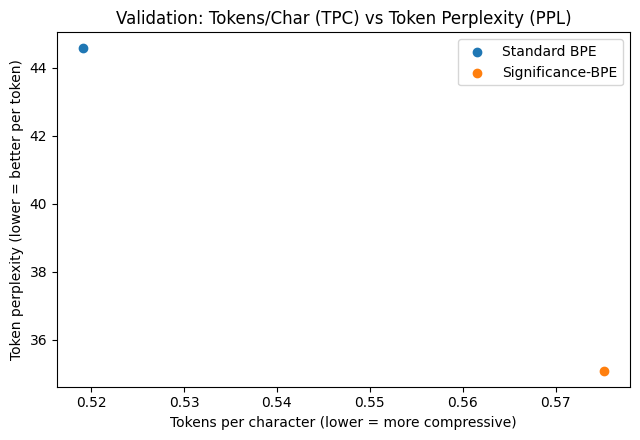

In [44]:
# ==============================
# Tokenizer Viz 1: TPC vs PPL scatter
# ==============================
import matplotlib.pyplot as plt

# Fallback: compute BPC if not already in memory
import math
LN2 = math.log(2.0)

def _bpc(nll_tok, tpc):
    return (nll_tok * tpc) / LN2

# Try to assemble points from available variables (single-run or grid)
points = []

# single-run points
if all(k in globals() for k in ["val_ppl_f","val_ppl_s","val_tpc_f","val_tpc_s"]):
    points.append(("Standard BPE", float(val_tpc_f), float(val_ppl_f)))
    points.append(("Significance-BPE", float(val_tpc_s), float(val_ppl_s)))

# optional: if we ran a vocab grid and kept results in grid_rows (list of tuples)
# expected format from earlier cells: (V, val_nllc_f, val_nllc_s, test_nllc_f, test_nllc_s, val_tpc_f, val_tpc_s)
if "grid_rows" in globals() and isinstance(grid_rows, (list, tuple)) and len(grid_rows) > 0:
    for row in grid_rows:
        if len(row) >= 7:
            V, vnf, vns, *_rest = row
            tpcf, tpcs = row[-2], row[-1]
            # approximate token-PPL not stored in grid_rows; skip
            pass

if len(points) == 0:
    raise RuntimeError("Missing variables for plotting. Run the training/eval cells first.")

plt.figure(figsize=(6.5,4.5))
for name, tpc, ppl in points:
    plt.scatter([tpc], [ppl], label=name)
plt.title("Validation: Tokens/Char (TPC) vs Token Perplexity (PPL)")
plt.xlabel("Tokens per character (lower = more compressive)")
plt.ylabel("Token perplexity (lower = better per token)")
plt.legend()
plt.tight_layout()
plt.show()

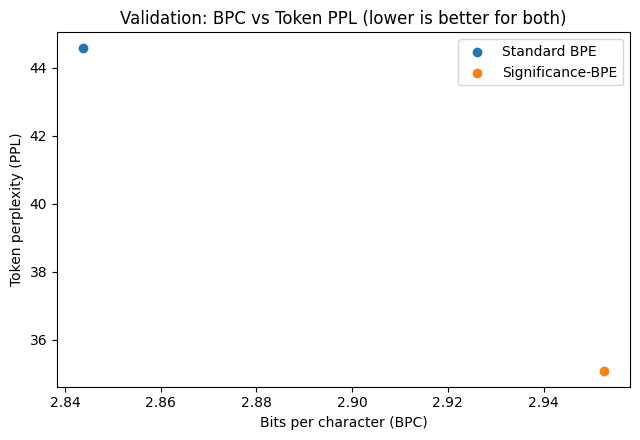

Note: Comparing token PPL across tokenizers is not apples-to-apples; BPC is the tokenizer-normalized view.


In [45]:
# ==============================
# Tokenizer Viz 2: BPC vs PPL (Pareto view)
# ==============================
import matplotlib.pyplot as plt
import math

LN2 = math.log(2.0)
def bpc(nll_tok, tpc): return (nll_tok * tpc) / LN2

# Compute val_bpc_* if needed
if "val_bpc_f" not in globals() and all(k in globals() for k in ["val_nll_f","val_tpc_f"]):
    val_bpc_f = bpc(val_nll_f, val_tpc_f)
if "val_bpc_s" not in globals() and all(k in globals() for k in ["val_nll_s","val_tpc_s"]):
    val_bpc_s = bpc(val_nll_s, val_tpc_s)

if not all(k in globals() for k in ["val_ppl_f","val_ppl_s","val_bpc_f","val_bpc_s"]):
    raise RuntimeError("Missing val_ppl_* / val_bpc_* variables. Run evaluation cells first.")

pts = [
    ("Standard BPE", float(val_bpc_f), float(val_ppl_f)),
    ("Significance-BPE", float(val_bpc_s), float(val_ppl_s)),
]

plt.figure(figsize=(6.5,4.5))
for name, xbpc, yppl in pts:
    plt.scatter([xbpc], [yppl], label=name)

plt.title("Validation: BPC vs Token PPL (lower is better for both)")
plt.xlabel("Bits per character (BPC)")
plt.ylabel("Token perplexity (PPL)")
plt.legend()
plt.tight_layout()
plt.show()

print("Note: Comparing token PPL across tokenizers is not apples-to-apples; BPC is the tokenizer-normalized view.")

tok_f: OK
tok_s: OK


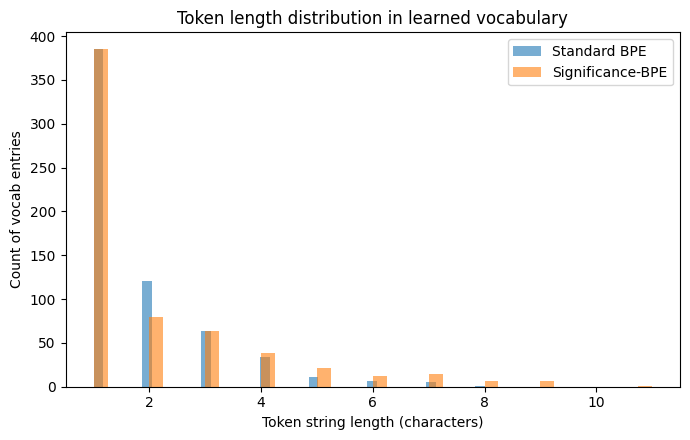

Standard BPE: mean_len=1.73, p95=4
Significance-BPE: mean_len=2.05, p95=6


In [46]:
# ==============================
# Tokenizer Viz 3: Token length histogram (vocab)
# ==============================
import matplotlib.pyplot as plt

# --- Make sure the viz cells can find the tokenizers ---
if "tok_f" not in globals():
    if "tok_freq" in globals(): tok_f = tok_freq
    elif "tok_standard" in globals(): tok_f = tok_standard

if "tok_s" not in globals():
    if "tok_sigz" in globals(): tok_s = tok_sigz
    elif "tok_sig" in globals(): tok_s = tok_sig

print("tok_f:", "OK" if "tok_f" in globals() else "MISSING")
print("tok_s:", "OK" if "tok_s" in globals() else "MISSING")


def token_lengths(tok):
    # tok.vocab is expected to be dict token->id
    toks = list(getattr(tok, "vocab", {}).keys())
    # avoid special tokens if present
    toks = [t for t in toks if not (t.startswith("<") and t.endswith(">"))]
    return [len(t) for t in toks]

if not all(k in globals() for k in ["tok_f","tok_s"]):
    raise RuntimeError("Missing tokenizers tok_f/tok_s. Run tokenizer training cells first.")

lens_f = token_lengths(tok_f)
lens_s = token_lengths(tok_s)

plt.figure(figsize=(7,4.5))
plt.hist(lens_f, bins=40, alpha=0.6, label="Standard BPE")
plt.hist(lens_s, bins=40, alpha=0.6, label="Significance-BPE")
plt.title("Token length distribution in learned vocabulary")
plt.xlabel("Token string length (characters)")
plt.ylabel("Count of vocab entries")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Standard BPE: mean_len={sum(lens_f)/len(lens_f):.2f}, p95={sorted(lens_f)[int(0.95*len(lens_f))-1]}")
print(f"Significance-BPE: mean_len={sum(lens_s)/len(lens_s):.2f}, p95={sorted(lens_s)[int(0.95*len(lens_s))-1]}")

In [47]:
# ==============================
# Tokenizer Viz 4: Top-K merges inspection (with approximate score components)
# ==============================
import pandas as pd
import math
from collections import Counter

# We approximate merge-time statistics by replaying merges on a SAMPLE of the training text.
# This keeps the analysis lightweight. Increase SAMPLE_CHARS if you want more accurate counts.
SAMPLE_CHARS = 200_000
K = 50

def replay_merge_stats(tok, mode_name: str, text: str):
    if not hasattr(tok, "merges"):
        raise RuntimeError("Tokenizer object has no .merges attribute.")

    merges = tok.merges[:K]  # list of ((a,b), merged_token)
    # start from characters
    seq = list(text)
    rows = []
    for step, (pair, merged) in enumerate(merges, start=1):
        a, b = pair
        # counts before applying this merge
        pair_counts = Counter(zip(seq, seq[1:]))
        sym_counts  = Counter(seq)
        cxy = pair_counts.get((a,b), 0)
        cx = sym_counts.get(a, 0)
        cy = sym_counts.get(b, 0)
        N = max(len(seq)-1, 1)
        expected = (cx * cy) / N if N else 0.0
        z = (cxy - expected) / math.sqrt(expected + 1e-9) if expected > 0 else 0.0
        pmi = math.log((cxy * N + 1e-9) / (cx * cy + 1e-9)) if (cx*cy)>0 else 0.0

        rows.append({
            "step": step,
            "pair": f"{repr(a)} + {repr(b)}",
            "merged": repr(merged),
            "cxy": cxy,
            "cx": cx,
            "cy": cy,
            "expected": expected,
            "z": z,
            "pmi": pmi,
        })

        # apply merge once
        out=[]
        i=0
        L=len(seq)
        while i<L:
            if i<L-1 and seq[i]==a and seq[i+1]==b:
                out.append(merged)
                i += 2
            else:
                out.append(seq[i])
                i += 1
        seq = out

    df = pd.DataFrame(rows)
    df["mode"] = mode_name
    return df

if not all(k in globals() for k in ["tok_f","tok_s","train_text_small"]):
    raise RuntimeError("Need tok_f, tok_s, and train_text_small defined.")

sample = train_text_small[:SAMPLE_CHARS]

df_fm = replay_merge_stats(tok_f, "Standard BPE", sample)
df_sm = replay_merge_stats(tok_s, "Significance-BPE", sample)

# Show side-by-side top merges by step
display(df_fm.head(20))
display(df_sm.head(20))

# Quick view: which merges have highest z / PMI (in the sample)
print("\nTop Significance-BPE merges by z (sample-estimated):")
display(df_sm.sort_values("z", ascending=False).head(15)[["step","pair","merged","cxy","z","pmi"]])

print("\nTop Significance-BPE merges by PMI (sample-estimated):")
display(df_sm.sort_values("pmi", ascending=False).head(15)[["step","pair","merged","cxy","z","pmi"]])

,step,pair,merged,cxy,cx,cy,expected,z,pmi,mode
0,1,'e' + ' ','e ',5949,18510,38052,3521.730209,40.901573,0.524271,Standard BPE
1,2,'s' + ' ','s ',4528,9561,32103,1581.740701,74.080400,1.051754,Standard BPE
2,3,'t' + 'h','th',3916,12856,7365,499.596036,152.847988,2.059026,Standard BPE
3,4,'d' + ' ','d ',3539,6161,27575,915.323723,86.720723,1.352322,Standard BPE
4,5,'n' + ' ','n ',3006,10632,24036,1403.608298,42.770638,0.761564,Standard BPE
5,6,'e' + 'r','er',2640,12561,9730,682.552482,74.924198,1.352695,Standard BPE
6,7,'t' + ' ','t ',2171,8940,21030,1065.679256,33.859073,0.711575,Standard BPE
7,8,'i' + 'n','in',2080,10690,7626,467.844706,74.534272,1.491987,Standard BPE
8,9,'th' + 'e ','the ',2171,3916,5949,135.309775,175.003649,2.775376,Standard BPE
9,10,'a' + 'n','an',1932,12562,5546,409.819187,75.191734,1.550595,Standard BPE


,step,pair,merged,cxy,cx,cy,expected,z,pmi,mode
0,1,'@' + '-','@-',319,866,336,1.454887,263.263566,5.390263,Significance-BPE
1,2,'@-' + '@','@-@',319,319,547,0.873863,340.312288,5.900023,Significance-BPE
2,3,'\n' + '\n','\n\n',484,968,968,4.700137,221.081320,4.634493,Significance-BPE
3,4,'t' + 'h','th',3916,12856,7365,476.095476,157.651955,2.107208,Significance-BPE
4,5,'1' + '9','19',218,696,342,1.220921,196.188508,5.184889,Significance-BPE
5,6,'th' + 'e','the',2749,3916,18510,372.209322,123.196200,1.999536,Significance-BPE
6,7,'2' + '0','20',131,394,424,0.870111,139.505025,5.014332,Significance-BPE
7,8,'i' + 'n','in',2955,10690,10632,592.381439,97.071757,1.607103,Significance-BPE
8,9,'in' + 'g','ing',1027,2955,3074,48.085153,141.169025,3.061424,Significance-BPE
9,10,'T' + 'h','Th',451,641,3449,11.767071,128.044436,3.646162,Significance-BPE



Top Significance-BPE merges by z (sample-estimated):


,step,pair,merged,cxy,z,pmi
24,25,'@.' + '@','@.@',62,413.277165,7.921828
1,2,'@-' + '@','@-@',319,340.312288,5.900023
0,1,'@' + '-','@-',319,263.263566,5.390263
17,18,"'@,' + '@'","'@,@'",52,228.826116,6.916664
23,24,'@' + '.','@.',62,221.257358,6.674047
2,3,'\n' + '\n','\n\n',484,221.081320,4.634493
44,45,'= ' + '= ','= = ',290,204.392626,4.983946
16,17,"'@' + ','","'@,'",52,199.105806,6.639047
4,5,'1' + '9','19',218,196.188508,5.184889
45,46,'= = ' + '= ','= = = ',78,186.055542,6.099873



Top Significance-BPE merges by PMI (sample-estimated):


,step,pair,merged,cxy,z,pmi
24,25,'@.' + '@','@.@',62,413.277165,7.921828
17,18,"'@,' + '@'","'@,@'",52,228.826116,6.916664
23,24,'@' + '.','@.',62,221.257358,6.674047
16,17,"'@' + ','","'@,'",52,199.105806,6.639047
45,46,'= = ' + '= ','= = = ',78,186.055542,6.099873
47,48,'= = = ' + '\n\n','= = = \n\n',39,125.907657,6.012438
1,2,'@-' + '@','@-@',319,340.312288,5.900023
46,47,'= = ' + '\n\n','= = \n\n',65,138.369672,5.692226
21,22,'20' + '1','201',73,138.166826,5.574069
0,1,'@' + '-','@-',319,263.263566,5.390263


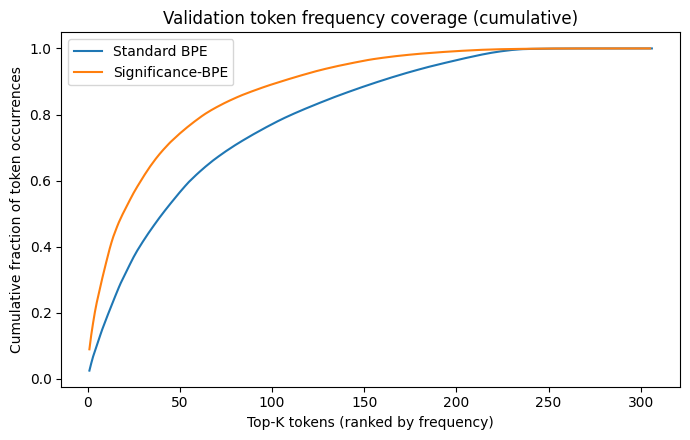

Top-  50 coverage | Standard=0.565  Sig=0.742
Top- 100 coverage | Standard=0.771  Sig=0.891
Top- 200 coverage | Standard=0.964  Sig=0.992
Top- 500 coverage | Standard=1.000  Sig=1.000
Top-1000 coverage | Standard=1.000  Sig=1.000


In [48]:
# ==============================
# Tokenizer Viz 5: Coverage curve (val-set token frequency concentration)
# ==============================
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

def coverage_curve(token_ids):
    cnt = Counter(token_ids)
    freqs = np.array(sorted(cnt.values(), reverse=True), dtype=np.float64)
    total = freqs.sum() if len(freqs) else 1.0
    cum = np.cumsum(freqs) / total
    x = np.arange(1, len(freqs)+1)
    return x, cum

if not all(k in globals() for k in ["va_f","va_s"]):
    raise RuntimeError("Need va_f and va_s (encoded validation tokens). Run encoding first.")

x_f, cum_f = coverage_curve(va_f)
x_s, cum_s = coverage_curve(va_s)

plt.figure(figsize=(7,4.5))
plt.plot(x_f, cum_f, label="Standard BPE")
plt.plot(x_s, cum_s, label="Significance-BPE")
plt.title("Validation token frequency coverage (cumulative)")
plt.xlabel("Top-K tokens (ranked by frequency)")
plt.ylabel("Cumulative fraction of token occurrences")
plt.legend()
plt.tight_layout()
plt.show()

# Report coverage at a few cutoffs
def at_k(x, cum, k):
    if k <= 0: return 0.0
    if k >= len(cum): return float(cum[-1])
    return float(cum[k-1])

for k in [50, 100, 200, 500, 1000]:
    print(f"Top-{k:4d} coverage | Standard={at_k(x_f,cum_f,k):.3f}  Sig={at_k(x_s,cum_s,k):.3f}")